

# Project Data Science
***Auteurs : DIALLO Bintou, RIPOLL Thomas***

***Thématique Business:***

Fidélisation et anticipation de la perte de clientèle dans les télécoms

***Contexte métier:***

Telco est une entreprise de télécommunications qui fournit des services essentiels de téléphonie et d'accès à internet. Son rôle principal est d'assurer une connectivité fiable tout en accompagnant ses abonnés au quotidien. À travers son service client, elle se charge de résoudre d'éventuelles pannes techniques et de gérer toutes les demandes liées aux abonnements, aux équipements ou à la facturation.

***Jeu de données:***

* **Source de données :** [Kaggle.com](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
* **Nom du dataset :** `WA_Fn-UseC_-Telco-Customer-Churn`
* **Volume :** 977,5 Ko, 7 043 lignes
* **Variables :** 23 variables au total (String : 12, Boolean : 5, Integer : 2, Other : 2). Ces variables se divisent en trois grandes catégories :
    * **Données démographiques :** Sexe, âge, situation familiale.
    * **Services souscrits :** Téléphone, lignes multiples, internet, sécurité en ligne, support technique, streaming, etc.
    * **Informations de compte :** Ancienneté du client, type de contrat, méthode de paiement, facturation mensuelle et totale.

***Problématique business:***

Nous sommes Data Scientist au sein d’une entreprise de télécommunication Telco. Notre entreprise souhaiterais prévoir les moments où les clients seraient les plus à même de résilier leurs abonnements et services souscrits au sein de notre entreprise, afin de savoir quand leur proposer des offres, ou mettre en place différentes techniques marketing pour de les fidéliser de nouveau, et éviter qu’ils ne se désabonnent. Parvenir à prédire ceci permettrait à l’entreprise d’éviter une perte de clients et donc une potentielle baisse de leur chiffre d’affaire.


***Objectif Data Science:***

1. Réaliser une analyse exploratoire (EDA) pour identifier les facteurs qui influencent le plus le départ d'un client (ex: type de contrat, absence de support technique, facturation élevée).

2. Développer un modèle de classification binaire (Supervised Learning) capable de prédire avec précision la probabilité de désabonnement d'un client (Churn = Oui ou Non) à partir de ses caractéristiques et de son historique.

##  Analyse exploratoire des données (EDA)
À réaliser dans un notebook Jupyter (.ipynb) avec analyse de la structure, statistiques
descriptives, valeurs manquantes, visualisations, corrélations, outliers et hypothèses.

### EDA-1 : Analyse de la structure du dataset
Vérification de la taille des données, du nom des colonnes et du type de variables:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# 1. Chargement du fichier de données
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Analyse de la structure (Taille et types de données)
print("Taille du dataset :", df.shape)
print("-" * 40)
df.info()

# 3. Affichage des 5 premières lignes pour un aperçu
display(df.head())

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Taille du dataset : (7043, 21)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract         

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Le dataset contient 7043 lignes et 21 colonnes.


Interprétation : Nous commençons par faire cet étape afin d'avoir un aperçu global de notre dataset et des données qu'il contient, ainsi que le profil client.

Volume et pertinence : Le dataset contient 7043 lignes et 21 colonnes. C'est un volume de données tout à fait satisfaisant pour entraîner notre algorithme.

 On peut voir qu'une grande partie des données est représentée sous forme "Yes" ou "Non", semblable à un fonctionnement booléen (par exemple : La colonne "partner").

 Le résultat de la colonne " Non-Null Count" nous confirme que notre dataset est bien remplie pour toute sles colonnes

#EDA-2 : Statistiques descriptives

Analyse des moyennes, valeurs minimales et maximales pour comprendre la distribution de nos clients.

In [3]:
#stats des colonnes avec des nombres (moyenne, min, max, etc.)
display(df.describe())

#sats des colonnes de texte (nb de categories uniques, categorie la + frequente)
display(df.describe(include='O'))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Interprétation :

##Variables numériques :

- On remarque que l'ancienneté (tenure) moyennes de nos clients est de 32 mois mais qu'il y a de gros écarts : le minimum allant de 0 (clients tout nouveux) et maximum atteignant 72

- Pour ce qui est du prix payé, la facture mensuelle varie de 18,25 à 118,75, avec une moyenne autour de 64,76

- Etant donné que SeniorCitizen est un booléen : valeur à 0 ou 1. La moyenne à environ 0.16 nous fait comprendre que nous avons environ 16% de nos clients étant seniors

##Variables catégorielles :    

- Pour notre colonne la plus importante : churn, nous pouvons voir que la valeur la plus fréquente est "No", ce qui signifie que la plupart des clients restent et nous pouvons voir que nous avons un jeu de données déséquilibré de par le fait qu'il y ait plus de "no" que de "yes".

- Nous pouvons aussi voir que le type de contrat le plus répendu est le "month-to-month" : c'est trop tôt pour affirmer si cela a un impact sur la volonté d'un utilisateur de partir mais celareste bien à garder en têtepour de futures hypothèses.

### EDA-3. Gestion des valeurs manquantes et recherches des doublons

Recherche des données vides dans notre dataset. Nous avons repéré un problème de format sur les colonnes :
1.  TotalCharges : Objet -> numerique
2.  SeniorCitiezn : Numerique -> Catégory (On remplace également 0 ou 1 par "Yes" ou "Non")
3. Colonnes Objets : Objet -> catégotry (On remarque sur ses colonnes qu'il n'y a que 4 valeurs uniques au maximun, c'est donc le choix le plus judicieux )

In [4]:
#cast de TotalCharges en numérique car avant c'était txt
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacer les 0 et 1 par "No" et "Yes"
# pour garder une belle cohérence avec les autres variables comme "Partner" ou "Dependents"
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

#Transformation des types objets en category pour plus de coherence
colonnes_textes = df.select_dtypes(include=['object']).columns
for col in colonnes_textes:
    df[col] = df[col].astype('category')

# nb de valeurs manquantes dans chaque colonne
print(df.isnull().sum())

#suppresion valeurs manquantes
df = df.dropna()

# Recherche des doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
df = df.drop_duplicates()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Nombre de doublons : 0


Interprétation :

- Le fait de forcer en valeur numériques la colone TotalCharges a mis en évidence les espaces vides, les transformant en valeurs nulles, indiquant qu'il y a 11 valeurs nulles. Nous les avons alors supprimé, leur nombre étant dérisoire comparé au nombre totale de lignes que nous avons, cela ne posera pas de soucis.

- On a remplacé le 0 et le 1 du tableau pour avoir le même focntionnement dans tout le tableau.

- EN remplaçant toutes les colonnes de type texte en type category nous permettons qu'il y a moins de type à gérer, permettant une amelioration de la performance en uniformisant

- L'absence de doublon : La vérification nous confirme que notre jeu de données est sain à ce niveau-là, avec 0 ligne dupliquée.



In [5]:
#Verification des types des colonnes après les transformations
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   category
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

Interprétation :    

Maintenant que notre tableau est propre et allégé. Chaque colonne a enfin le bon format : des vrais nombres pour les prix et l'ancienneté, et des catégories pour le texte.

### EDA-4. Recherche des Outliers (=Valeurs aberrantes)
Nous cherchns à repérer si certains clients ont des facturations ou des anciennetés anormales. Afin d'éviter que des variable extrêmes ne faussent nos analyses.

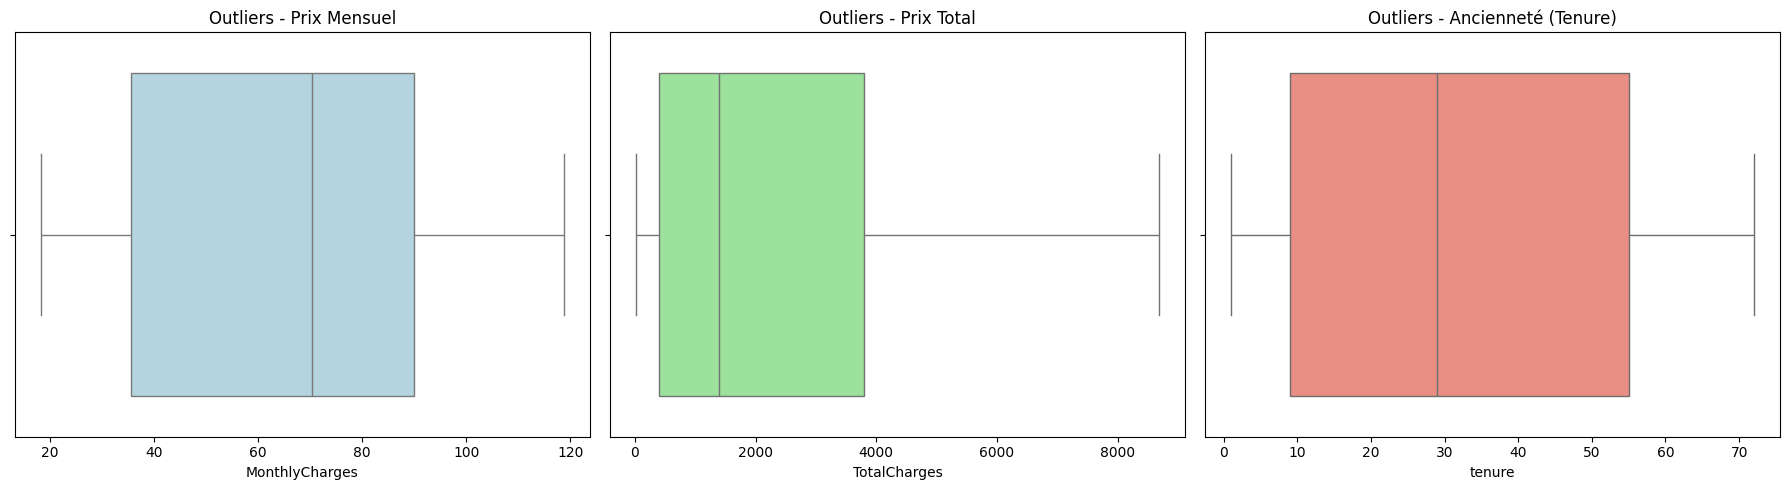

In [6]:
# On augmente un peu la largeur (18 au lieu de 12) pour que les 3 soient bien lisibles
plt.figure(figsize=(18, 5))

# 1. Boxplot pour les charges mensuelles (Grille 1x3, Position 1)
plt.subplot(1, 3, 1)
sns.boxplot(x=df['MonthlyCharges'], color='lightblue')
plt.title('Outliers - Prix Mensuel')

# 2. Boxplot pour le total payé (Grille 1x3, Position 2)
plt.subplot(1, 3, 2)
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Outliers - Prix Total')

# 3. Boxplot pour l'ancienneté (Grille 1x3, Position 3)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['tenure'], color='salmon')
plt.title('Outliers - Ancienneté (Tenure)')

plt.tight_layout()
plt.show()

Interprétation :    

Nous pouvons voir à parir de nos graphiques d'outliers que nos données pour le prix mensuel, le prix toltal et l'ancienneté ne sont pas abbérentes (de par l'absence de points en dehors de nos limites et forme nette de notre graphique)
Notre graphique ne contient donc pas de valeurs aberrantes, selon les métriques que nous avons choisies.

Ce que ça peut signifier :    

- L'absence d'outliers signifie d'abord qu'il n'y a pas eu d'erreur informatique ou de faute de frappe au moment où les données ont été rentrées (par exemple : une personne payant un prix de 999999 pour son abonnement)

- La politique tarifaire de notre entreprise ne suit pas une évolution "étrange", les fourchettes de prix peuvent être vues comme classiques, le contraire ayant pu avoir une incidence sur le churn de certains clients.

### EDA-5 Visualisations
Nous souhaitons faire des visualisations pour essayer comprendre ce qui pousse un client au désabonnement

/tmp/ipykernel_19568/1045986789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


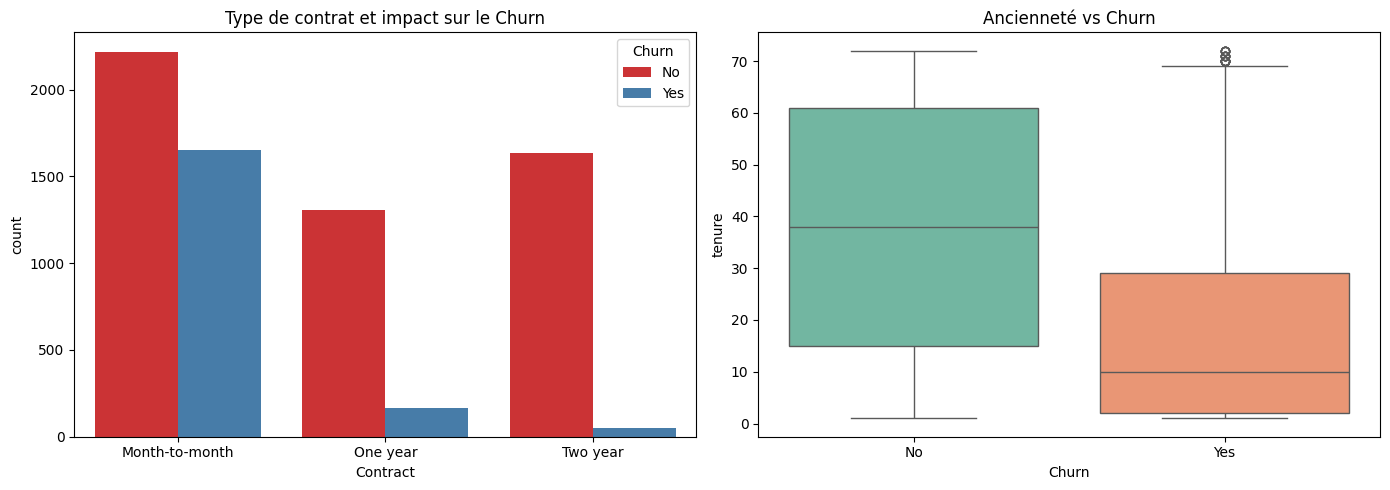

In [7]:
plt.figure(figsize=(14, 5))

# 1er Graphique : L'impact du type de contrat
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Type de contrat et impact sur le Churn')

# 2ème Graphique : Impact de l'ancienneté
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Ancienneté vs Churn')

plt.tight_layout()
plt.show()


Interprétation :    

Graphique 1 :     
- Le premier graphique montre une tendance trsè forte : la majorité des clients qui vont nous quitter sont généralement des clients ayant un type d'abonneent de type "month-to-month".
- Les clients ayant des abonnements les engageant sur une année complète ou deux années complètes sont ceux qui se désabonnent le moins de nos services.

Graphique 2 :
- Le deuxième graphique nous montre que la majorité des personnes qui ont en effet rélisilié leur abonnement (=churn) étaient dans la majorité des personnes ayant une faible ancienneté (allant de 0 à 30 mois et oscillant le plus souvent autour des 10 mois, et avec quelques valeurs n'entrant pas dans cette généralisation, comme le montre les cercles à l'extrémité de l'axe).

- Tandis que ceux maintenant leur abonnement ont souvent une ancienneté allant de 15 à 60 mois (ce qui est en moyenne plus long que lancienneté des personnes résiliant leurs abonnements).

- On peut donc en déduire que les clients ayant l'ancienneté la moins élevée sont ceuxx qui sont les plus susceptibles de nous quitter, tandis que la tendance est que plus les clients ont d'ancienneté, plus ils sont fidélisés et moins ils résilient nos services.

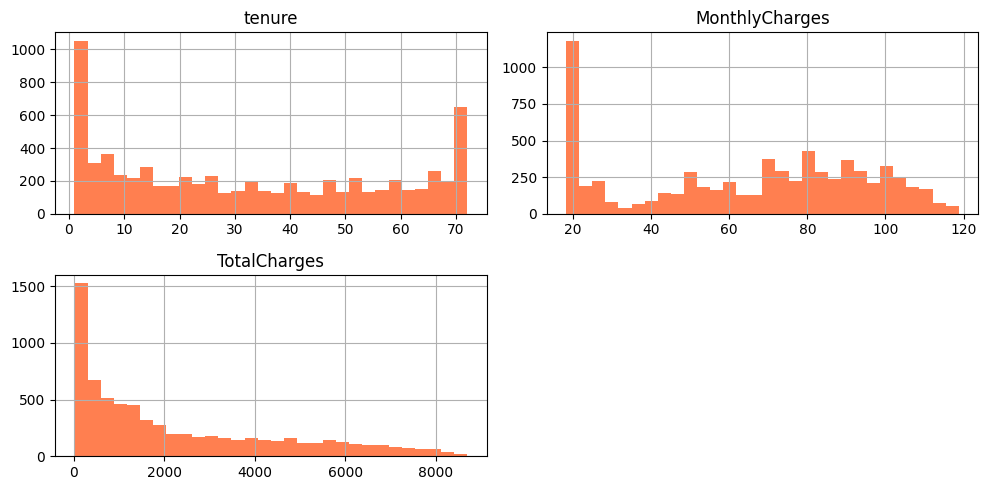

In [8]:
# Histogrammes pour analyser les distributions
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(10, 5), color='coral')
plt.tight_layout()
plt.show()

Interprétation :    

- Ancienneté (tenure) : On observe un pic des clients très récents (vers 0) ainsi qu'un pic des clients très anciens (vers 70). On peut en déduire que le défi de l'enteprise serait de maintenir les nouveaux clients assez longtemps pour qu'ils deviennent des clients de longue datemoins de chance de se désinscrire de nos services une fois fidélisés.

- Monthly Charges : On peut voir qu'une grande partie des personnes payent un abonnement d'une valeur de 20 tandis qu'un grand étalé groupe de personnes payent plus cher des prix allant de 40 à 100. Moins de personnes paynt dans les environs de 40 ou 120. Une interprétatin possible pourrait être que beaucoup de personnes ne payent qu'un seul abonneme nt (expliquant le pic d'abonnements peu cher), tandis que certaines autres personnes font des regroupements d'offres.

- TotalCharges :    La majorité des données se rrouvent sur la droite et même près de 0. Ce qui s'explique par la fait que la majorité des clients sont des clients avec peu d'ancienneté (comme vu dans de précédents graphiques) ce qui explique que la majorité des clients n'ont pas un total de dépense très élevé.

In [9]:
# Preuve numérique : Calcul exact de la skewness
skewness_total = df['TotalCharges'].skew()
print(f"La skewness de TotalCharges est de : {skewness_total:.2f}")

skewness_tenure = df['tenure'].skew()
print(f"La skewness de tenure est de : {skewness_tenure:.2f}")


La skewness de TotalCharges est de : 0.96
La skewness de tenure est de : 0.24


Interprétation :    

Pour TotalCharges la skewness est de 0.96, montrant qu'il y a une forte asymétrie des données ce que l'histogramme montrait avec uen forte asymétrie à droite. Cela pourra être corrigé par la suite lorsque l'on préparera nos données.

Pour Tenure, on pouvait voir que l'histogramme se rapprochait davantage à une forme de U, faisant penser à une possible symétrie des données, le calcul de la skewness montre qu'en effet contrairement au calcul pour total charges, le résultat semble plus bas et peut vouloir montrer une symétrie plus importante mais pas avérée étant donné que le résultat n'est pas de 0. Cependant cette forme de U confirme qu'il ne s'agit surement pas là d'une loi normale (qui se rapproche plus d'une forme de cloche.

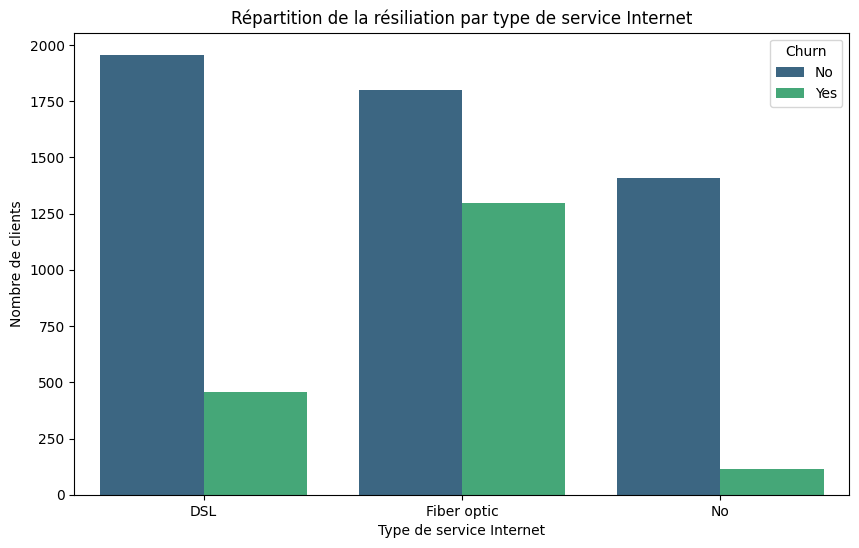

In [10]:
plt.figure(figsize=(10, 6))
# On crée un graphique à barres montrant le nombre de clients par service, coloré par Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')

plt.title('Répartition de la résiliation par type de service Internet')
plt.xlabel('Type de service Internet')
plt.ylabel('Nombre de clients')
plt.show()

Interprétation :    

- On peut voir que la proportion de personnes qui résilient leur abonnement DSL est bien moins élevée que celles de personnes qui le maintiennent

- On peut également voir que pour ce qui est de la fibre optique, la proportion de personnes résiliant leurs abonnement est presque identique à celle des personnes le maintenant, ce qui peut faire se poser des questions sur la satisfaction des clients quant aux services de fibre optique, d'un point de vue global.

- No : cette colonne signifie qu'ils ne fournissent pas de services. Cela s'applique aux personnes ne prenant pas de service internet, et représentent tout le reste des clients (les clients ne prenant qu'un service téléphonique par exemple seront représenté ici), on voit que les personnes qui ne prennent pas de services internet ont bien moins tendance à se dasabonner de nos services.

Ainsi, on peut en déduire que la majorité du temps les services se faisant résilier sont des services en rapport avec internet. Cela peut nous amener à nous poser des questions quant à la satisfaction de nos services internet ou d'autres facteurs tel que leur prix, etc. Tandis que cela peut nous conforter dans l'idée que nos services hors internet satisfont globalement nos clients.

#Hypothèses

Selon les différentes obser ations que nous avons faites, nous pouvez émettre quelques hypothèses, qui seront utiles avant de passer aux étapes de modélisation :    

- Hypothèse 1 - Une vulnérabilité au niveau des nouveux clients :    
Les observations que nous avons eu tendent à montrer une certaine vulnérabilité des nouveaux clients qui semblent plus à même de résilier nos services. Nous pouvons ob server que la majorité de nos clients tendent à quitter notre enteprise dans les premiers mois et sont souvent des personnes ayant des abonnements de type month-to-month. A l'inverse, les contrats plus long (d'un an ou deux ans) ainsi que l'ancienneté du client semblent les fidéliser davantage.

- Hyphothèse 2 - Problème notre offre de ficbre optique :    
Tout comme l'un de nos graphiques précédents le montrait, parmi tous les services que nous proposons, l'un semble davantage entraîner des désabonnements que tous les autres services proposés par notre entreprise. Cela pourrait indiquer un problème de qualité de notre service ou un désavantage face à la conccurence proposant des services similaires.

- Hyphothèse 3 - Existance de deux tendances tarifaires distinctes :    
On peut voir qu'une très grande portion des abonnés ont tendance à dépenser de petites sommes, tandis qu'une autre grande partie a tedance à dépense des sommes plus élevées sans qu'il n'y ait un pic de concentration des clients pour l'un de ces différentes sommes élevées. Ce qu'il serait intéressant de jauger, serait la possible existence d'une corrélation entre lee désabonnements, en fonctio du prix payé par les abonnés.

### EDA-6 - Nettoyage et préprocessing

Son but est simple : transformer un fichier texte lisible par un humain en un tableau mathématique compréhensible par une machine.

In [11]:

# On rempllace "Yes" et "No" de Churn par 0 ou 1, le machine learning se fait via des valeurs numérioques
df['Churn'] = df['Churn'].map({'No':0 ,'Yes': 1}).astype('category')

Pour valider scientifiquement la pertinence de nos variables catégorielles par rapport à la cible (Churn), nous utilisons deux indicateurs complémentaires.

# A. Le Test du Chi-deux (χ²) : "Le lien existe-t-il ?"

C’est le test de l'indépendance statistique. Il permet de savoir si la distribution d'une variable (ex : le type de contrat) est liée à celle de la cible.

**Indicateur :** La p-value.

**Seuil de décision :**  
- **p-value < 0.05 :** Le lien est dit *significatif*. On est sûr à 95 % que la variable influence le Churn (ce n'est pas dû au hasard).  
- **p-value > 0.05 :** On ne peut pas prouver de lien. La variable est statistiquement *aveugle* face au Churn.

# B. Le V de Cramér : "Le lien est-il puissant ?"

Une fois qu'un lien est confirmé par le Chi-deux, le V de Cramér mesure l'intensité de cette relation sur une échelle de 0 à 1.

**Interprétation :**  
- **0.00 à 0.10 :** Lien très faible ou négligeable.  
- **0.10 à 0.30 :** Lien modéré.  
- **Supérieur à 0.30 :** Lien fort (ce sont les variables prédictives majeures).

In [12]:
import scipy.stats as stats
import pandas as pd
import numpy as np

def analyse_cramer(colonne_etudiee, cible='Churn'):
    # On crée la table de contingence
    confusion_matrix = pd.crosstab(df[colonne_etudiee], df[cible])

    # SECURITÉ : Si la table est vide ou n'a qu'une seule ligne/colonne, le test Chi2 est impossible
    if confusion_matrix.size == 0 or confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        print(f"--- {colonne_etudiee} --- : Analyse impossible (données insuffisantes ou colonne vide)\n")
        return

    # Calcul du Chi2
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)

    # Calcul du V de Cramer
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"--- {colonne_etudiee} vs {cible} ---")
    print(f"p-value (Chi²) : {p:.5f}")
    print(f"V de Cramér : {v_cramer:.5f}\n")

# 1. On identifie les colonnes catégorielles présentes dans le DF actuel
colonnes_cat = df.select_dtypes(include=['object', 'category']).columns

# 2. On exclut Churn et on s'assure que les colonnes existent bien
colonnes_a_tester = [col for col in colonnes_cat if col != 'Churn']

print(f"Lancement de l'analyse pour {len(colonnes_a_tester)} variables :\n")

# 3. Boucle sécurisée
for col in colonnes_a_tester:
    try:
        analyse_cramer(col)
    except Exception as e:
        print(f"Erreur sur la colonne {col}: {e}")

Lancement de l'analyse pour 17 variables :

--- customerID vs Churn ---
p-value (Chi²) : 0.49439
V de Cramér : 1.00000

--- gender vs Churn ---
p-value (Chi²) : 0.49049
V de Cramér : 0.00822

--- SeniorCitizen vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.15010

--- Partner vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.14966

--- Dependents vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.16278

--- PhoneService vs Churn ---
p-value (Chi²) : 0.34992
V de Cramér : 0.01115

--- MultipleLines vs Churn ---
p-value (Chi²) : 0.00357
V de Cramér : 0.04004

--- InternetService vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.32191

--- OnlineSecurity vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.34699

--- OnlineBackup vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.29190

--- DeviceProtection vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.28116

--- TechSupport vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.34251

--- StreamingTV vs Churn 

#  Analyse des variables et recommandations de nettoyage

| Variable           | p-value (Chi²) | V de Cramér | Probabilité de suppression | Commentaire |
|-------------------|----------------|-------------|----------------------------|------------|
| customerID        | 0.49439        | 1.00000     | Très élevée                | Identifiant unique, inutile pour prédiction |
| gender            | 0.49049        | 0.00822     | Élevée                     | Pas de lien significatif avec le Churn |
| SeniorCitizen     | 0.00000        | 0.15010     | Faible                     | Lien faible mais significatif |
| Partner           | 0.00000        | 0.14966     | Faible                     | Lien faible mais significatif |
| Dependents        | 0.00000        | 0.16278     | Faible                     | Lien faible à modéré |
| PhoneService      | 0.34992        | 0.01115     | Élevée                     | Pas de lien significatif |
| MultipleLines     | 0.00357        | 0.04004     | Moyenne                     | Lien très faible |
| InternetService   | 0.00000        | 0.32191     | Faible                     | Lien fort, conserver |
| OnlineSecurity    | 0.00000        | 0.34699     | Faible                     | Lien fort, conserver |
| OnlineBackup      | 0.00000        | 0.29190     | Faible                     | Lien modéré à fort, conserver |
| DeviceProtection  | 0.00000        | 0.28116     | Faible                     | Lien modéré à fort, conserver |
| TechSupport       | 0.00000        | 0.34251     | Faible                     | Lien fort, conserver |
| StreamingTV       | 0.00000        | 0.23014     | Moyenne                     | Lien modéré, à évaluer |
| StreamingMovies   | 0.00000        | 0.23070     | Moyenne                     | Lien modéré, à évaluer |
| Contract          | 0.00000        | 0.40956     | Très faible                 | Facteur clé, à conserver absolument |
| PaperlessBilling  | 0.00000        | 0.19113     | Moyenne                     | Lien modéré, à évaluer selon modèle |
| PaymentMethod     | 0.00000        | 0.30296     | Faible                     | Lien fort, conserver |

# Justification des suppressions (Cleaning)

Sur la base de l'analyse automatisée des 17 variables, nous recommandons le nettoyage suivant :

---

## Colonnes à supprimer systématiquement

| Colonne       | Motif de suppression                                                                 | Preuve Statistique |
|---------------|--------------------------------------------------------------------------------------|------------------|
| customerID    | Identifiant unique, chaque ID est lié à une seule ligne, inutile pour la prédiction. | V = 1.000        |
| gender        | Aucune différence statistique de comportement entre les hommes et les femmes.       | p-value = 0.490  |
| PhoneService  | L'accès au service téléphonique n'influence pas significativement la décision de résilier. | p-value = 0.350  |

---

## Colonnes à conserver absolument

Ces variables présentent un lien fort ou très fort avec le Churn et sont critiques pour la performance du modèle :

| Colonne           | V de Cramér | Commentaire |
|-------------------|-------------|------------|
| Contract          | 0.40956     | Facteur clé, type d'engagement |
| OnlineSecurity    | 0.34699     | Forte influence, assistance technique |
| TechSupport       | 0.34251     | Forte influence, assistance technique |
| InternetService   | 0.32191     | Technologie (Fibre vs DSL) impacte la satisfaction |
| PaymentMethod     | 0.30296     | Influence notable sur le Churn |
| OnlineBackup      | 0.29190     | Lien modéré à fort, important à conserver |
| DeviceProtection  | 0.28116     | Lien modéré à fort, important à conserver |

---

## Colonnes à supprimer **si nécessaire** (simplification du modèle)

Ces variables ont un lien faible ou modéré et peuvent être retirées si le modèle doit être simplifié ou si elles génèrent de la redondance :

| Colonne           | V de Cramér | Commentaire |
|-------------------|-------------|------------|
| SeniorCitizen     | 0.15010     | Lien faible mais significatif |
| Partner           | 0.14966     | Lien faible mais significatif |
| Dependents        | 0.16278     | Lien faible à modéré |
| MultipleLines     | 0.04004     | Lien très faible |
| StreamingTV       | 0.23014     | Lien modéré |
| StreamingMovies   | 0.23070     | Lien modéré |
| PaperlessBilling  | 0.19113     | Lien modéré, à évaluer selon modèle |

In [13]:
cols_to_drop = ['customerID', 'gender', 'PhoneService']
df.drop(columns=cols_to_drop, inplace=True)


# Analyse des Corrélations (Variables Numériques)

Alors que le Chi-deux mesure l'indépendance entre catégories, la Corrélation de Pearson mesure la force et la direction du lien linéaire entre deux variables chiffrées. Le coefficient $r$ varie de -1 à +1.

---

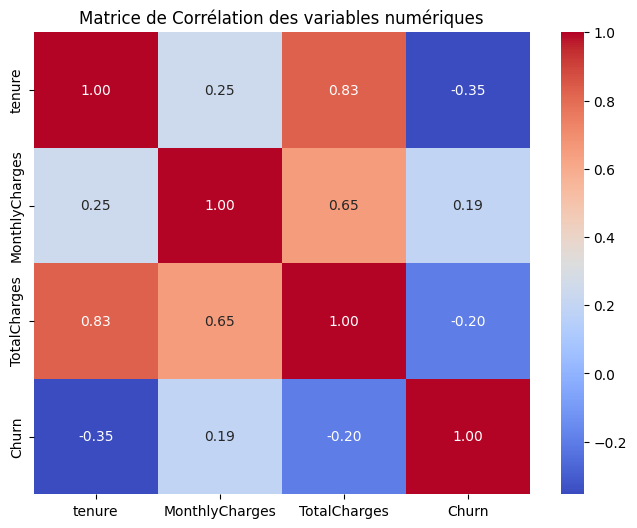

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques uniquement
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[num_cols].corr()

# Affichage de la Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des variables numériques')
plt.show()



## 1. Interprétation de la Heatmap

D'après les résultats affichés sur la matrice de corrélation :

| Lien analysé           | Coefficient (r) | Interprétation |
|------------------------|----------------|----------------|
| tenure vs Churn         | -0.35          | Forte corrélation négative. Plus l'ancienneté augmente, plus la probabilité de départ diminue (les clients anciens sont plus fidèles). |
| MonthlyCharges vs Churn | +0.19          | Corrélation positive faible. Les clients avec des factures mensuelles élevées ont une tendance légèrement plus forte à résilier. |
| TotalCharges vs Churn   | -0.20          | Corrélation négative faible. Ce lien est trompeur car il est fortement influencé par l'ancienneté. |

---

## 2. Détection de la Redondance (Multicolinéarité)

Un point crucial est la relation entre les variables explicatives elles-mêmes :

- **tenure vs TotalCharges ($r = 0.83$)** : Corrélation très élevée entre ces deux variables.  
  **Justification métier :** Plus un client reste longtemps (tenure), plus le cumul de ses factures (TotalCharges) est élevé.  
  Garder ces deux variables dans certains modèles de Machine Learning peut créer de la redondance.

---

## 3. Conclusion pour le Nettoyage

Sur la base de cette analyse, voici les choix retenus :

- **Conservation de tenure et MonthlyCharges** : Ce sont les deux signaux les plus "propres" pour prédire le désabonnement.  
- **Vigilance sur TotalCharges** : Comme elle est redondante avec l'ancienneté (83% de corrélation), nous pourrions envisager de la supprimer si le modèle final souffre d'instabilité, afin de simplifier l'algorithme.

---

### Résumé pour évaluation

- L'analyse par corrélation de Pearson confirme que **l'ancienneté** est le principal facteur de rétention ($r = -0.35$).  
Nous avons également identifié une **forte redondance** entre tenure et TotalCharges ($r = 0.83$), ce qui justifie une simplification potentielle des données lors de l'entraînement du modèle."
---

## 2. Détection de la Redondance (Multicolinéarité)

Un point crucial est la relation entre les variables explicatives elles-mêmes :

- **tenure vs TotalCharges ($r = 0.83$)** : Corrélation très élevée entre ces deux variables.  
-  **Justification métier :** Plus un client reste longtemps (tenure), plus le cumul de ses factures (TotalCharges) est élevé. Garder ces deux variables dans certains modèles de Machine Learning peut créer de la redondance.

---

## 3. Conclusion pour le Nettoyage (Preprocessing)

Sur la base de cette analyse, voici les choix retenus pour la suite :  

- **Conservation de tenure et MonthlyCharges** : Ce sont les deux signaux les plus "propres" pour prédire le désabonnement.  
- **Vigilance sur TotalCharges** : Comme elle est redondante avec l'ancienneté (83% de corrélation), il est possible de la supprimer si le modèle final souffre d'instabilité, afin de simplifier l'algorithme.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   category
 1   Partner           7032 non-null   category
 2   Dependents        7032 non-null   category
 3   tenure            7032 non-null   int64   
 4   MultipleLines     7032 non-null   category
 5   InternetService   7032 non-null   category
 6   OnlineSecurity    7032 non-null   category
 7   OnlineBackup      7032 non-null   category
 8   DeviceProtection  7032 non-null   category
 9   TechSupport       7032 non-null   category
 10  StreamingTV       7032 non-null   category
 11  StreamingMovies   7032 non-null   category
 12  Contract          7032 non-null   category
 13  PaperlessBilling  7032 non-null   category
 14  PaymentMethod     7032 non-null   category
 15  MonthlyCharges    7032 non-null   float64 
 16  TotalCharges      7032 non-nu

### Encodage binaire pour les colonnes avec exactement 2 valeurs uniques

L'objectif est de transformer les colonnes **catégorielles binaires** en format numérique exploitable par les algorithmes.
- On affiche toutes les valeurs unique de chaque colonnes de type category

---

### Identifier les colonnes binaires

- On cible uniquement les colonnes avec **exactement 2 valeurs uniques**.  
- On ignore les colonnes déjà numériques (`int` ou `float`).

- On transforme les colonnes category "Binaire" en Int64

In [16]:
for col in df.select_dtypes(include=['category']).columns:
    print(f"--- Colonne : {col} ---")
    print(f"Nombre de catégories : {df[col].nunique()}")
    print(f"Valeurs : {df[col].unique().tolist()}")
    print()

--- Colonne : SeniorCitizen ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']

--- Colonne : Partner ---
Nombre de catégories : 2
Valeurs : ['Yes', 'No']

--- Colonne : Dependents ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']

--- Colonne : MultipleLines ---
Nombre de catégories : 3
Valeurs : ['No phone service', 'No', 'Yes']

--- Colonne : InternetService ---
Nombre de catégories : 3
Valeurs : ['DSL', 'Fiber optic', 'No']

--- Colonne : OnlineSecurity ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : OnlineBackup ---
Nombre de catégories : 3
Valeurs : ['Yes', 'No', 'No internet service']

--- Colonne : DeviceProtection ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : TechSupport ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : StreamingTV ---
Nombre de catégories : 3
Valeurs : ['No', 'Yes', 'No internet service']

--- Colonne : StreamingMovies ---
Nomb

### Encodage binaire pour les colonnes avec exactement 3 valeurs uniques de type "Yes" , "No", "No internet service"

- On remarque qu'il y a des colonnes "Yes" , "No", ("No internet Service" ou "No phone service")
- On peux simplifier ses colonnes en remplacant 'No internet service' par "No"
- On applique ensuite la logique binaire vu ci-dessus

In [17]:
# Après avoir parcouru ses colonnes, on remarque que les colonnes ont des valeurs de type ["Yes", "No", "No internet service"]
# On remplace "No internet service" ou "No phone service"
cols_a_simplifier = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'MultipleLines',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_a_simplifier:
    if col in df.columns:
        # On remplace 'No internet service' par 'No'
        df[col] = df[col].replace(to_replace=r'^No .+$', value='No', regex=True)
        print(f"--- Colonne : {col} ---")
        print(f"Nombre de catégories : {df[col].nunique()}")
        print(f"Valeurs : {df[col].unique().tolist()}")
print("Simplification terminée avec Regex.")

--- Colonne : OnlineSecurity ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : OnlineBackup ---
Nombre de catégories : 2
Valeurs : ['Yes', 'No']
--- Colonne : DeviceProtection ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : MultipleLines ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : TechSupport ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : StreamingTV ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
--- Colonne : StreamingMovies ---
Nombre de catégories : 2
Valeurs : ['No', 'Yes']
Simplification terminée avec Regex.


In [18]:
# 1. Identifier les colonnes avec exactement 2 valeurs uniques
# On exclut les colonnes déjà numériques (float/int) pour ne cibler que le texte/catégories
colonnes_binaires = [col for col in df.columns if df[col].nunique() == 2]

print(f"Colonnes binaires détectées : {colonnes_binaires}")

# 2. Application de l'encodage binaire (0 et 1)
for col in colonnes_binaires:
    # On récupère les deux valeurs (ex: ['No', 'Yes'])
    valeurs = df[col].unique()
    print(f"Encodage de {col} : {valeurs[0]} -> 0, {valeurs[1]} -> 1")
    # Transformation
    df[col] = df[col].map({valeurs[0]: 0, valeurs[1]: 1})
    df[col] = df[col].astype("Int64")

# 3. Vérification du résultat
print("\n--- Vérification des types après encodage ---")
print(df[colonnes_binaires].dtypes)
df.head()
df.info()

df["Churn"].value_counts()

Colonnes binaires détectées : ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
Encodage de SeniorCitizen : No -> 0, Yes -> 1
Encodage de Partner : Yes -> 0, No -> 1
Encodage de Dependents : No -> 0, Yes -> 1
Encodage de MultipleLines : No -> 0, Yes -> 1
Encodage de OnlineSecurity : No -> 0, Yes -> 1
Encodage de OnlineBackup : Yes -> 0, No -> 1
Encodage de DeviceProtection : No -> 0, Yes -> 1
Encodage de TechSupport : No -> 0, Yes -> 1
Encodage de StreamingTV : No -> 0, Yes -> 1
Encodage de StreamingMovies : No -> 0, Yes -> 1
Encodage de PaperlessBilling : Yes -> 0, No -> 1
Encodage de Churn : 0 -> 0, 1 -> 1

--- Vérification des types après encodage ---
SeniorCitizen       Int64
Partner             Int64
Dependents          Int64
MultipleLines       Int64
OnlineSecurity      Int64
OnlineBackup        Int64
DeviceProtection    Int64
TechSupport  

,count
Churn,
0,5163
1,1869


#  Encodage et standardisation des données

Pour préparer les données au Machine Learning, nous appliquons trois transformations simples :

- **RobustScaler** : normalise les variables numériques pour qu'elles soient sur la même échelle.
- **Ordinal Encoding** : transforme les catégories avec un ordre logique en valeurs numériques.
- **One-Hot Encoding** : transforme les catégories sans ordre en colonnes binaires.

---

##  Méthodes utilisées

| Type de colonne | Colonnes Telco | Méthode | Pourquoi ? |
|-----------------|---------------|--------|------------|
| Numériques | tenure, MonthlyCharges, TotalCharges | RobustScaler | Met les variables sur la même échelle pour améliorer les performances du modèle |
| Ordinale | Contract,  InternetService,| Ordinal Encoding | Il existe un ordre : Mensuel < 1 an < 2 ans, De même pour le type d'internet : No < ADSL < Fibre |
| Nominale | PaymentMethod | One-Hot Encoding | Pas d'ordre entre ses catégories |

---

## Objectif

Obtenir un **dataset propre, numérique et équilibré** pour entraîner efficacement les modèles de Machine Learning.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

cols_numeriques = ['tenure', 'MonthlyCharges']
cols_numeriques_log = ['TotalCharges'] # Forte asymétrie (Skewness = 0.96)
cols_ordinales = ['Contract','InternetService']
cols_nominales = ['PaymentMethod']

categories_contract = ['Two year', 'One year', 'Month-to-month']
categories_InternetService = ['No','DSL','Fiber optic']


# 2. Création d'un mini-pipeline spécifique pour TotalCharges skewness = 0.96
log_scale_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, validate=False)), # 1. Redresse la courbe
    ('scaler', RobustScaler())                            # 2. Met à l'échelle
])

preprocessor = ColumnTransformer(
    transformers=[
        # Standardisation des valeurs numériques continues
        ('num', RobustScaler(), cols_numeriques),
       # Numériques avec correction d'asymétrie (TotalCharges)
        ('num_log', log_scale_transformer, cols_numeriques_log),
        # Encodage ordinal pour le contrat
        ('ord', OrdinalEncoder(categories=[categories_contract,categories_InternetService]), cols_ordinales),
        # Encodage One-Hot pour les variables nominales
        ('nom', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_nominales)
    ],
    # Les colonnes binaires (0/1) ne sont pas dans les listes ci-dessus.
    # remainder='passthrough' permet de les garder telles quelles !
    remainder='passthrough'
)

preprocessor.set_output(transform="pandas")



ColumnTransformer(remainder='passthrough',
                  transformers=[('num', RobustScaler(),
                                 ['tenure', 'MonthlyCharges']),
                                ('num_log',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', RobustScaler())]),
                                 ['TotalCharges']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Two year',
                                                             'One year',
                                                             'Month-to-month'],
                                                            ['No', 'DSL',
                                                             'Fiber optic']]),
                                 ['Contract', 'InternetService']),
                                ('nom',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['PaymentMethod'])])

In [20]:
print("--- Préparation pour le Machine Learning ---")

# 1. Séparation de la cible (y) et des caractéristiques (X)
# Assure-toi que la colonne s'appelle bien 'Churn', sinon adapte le nom
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Découpage en Train (80%) et Test (20%)
# stratify=y est crucial ici : il garantit qu'il y aura le même pourcentage de désabonnements dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Application du preprocessor (La règle d'or anti-triche !)
# On utilise fit_transform SUR LE TRAIN pour que le RobustScaler apprenne les médianes
X_train_final = preprocessor.fit_transform(X_train)

# On utilise UNIQUEMENT transform SUR LE TEST (le modèle découvre ces données, il ne doit pas s'en servir pour ajuster le scaler)
X_test_final = preprocessor.transform(X_test)

print("Dimensions X_train :", X_train_final.shape)
print("Dimensions X_test  :", X_test_final.shape)
print("Dimensions y_train :", y_train.shape)

--- Préparation pour le Machine Learning ---
Dimensions X_train : (5625, 20)
Dimensions X_test  : (1407, 20)
Dimensions y_train : (5625,)


In [21]:
print(df.columns.tolist())
print("\n----------Information du dataframe df--------------------")
print("colonnes du df avant Encoding :",df.columns.tolist())

df.info()
print("\n\n")

print("---------- Information du dataframe d'entraînement (X_train_final) ----------")
print("Colonnes après Encoding :", X_train_final.columns.tolist())
X_train_final.info()



['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

----------Information du dataframe df--------------------
colonnes du df avant Encoding : ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   Int64   
 1   Partner           7032 non-null   Int64   
 2   Dependents        7032 non-null   Int64   

# Préparation finale des données pour le Machine Learning

Cette étape a converti notre base de données brute en une matrice numérique saine, prête pour l'apprentissage de l'algorithme :

- **Nettoyage ciblé (Regex)** : Les variantes de non-souscription (« No internet/phone service ») ont été unifiées en « No », allégeant les données et évitant la multicolinéarité.

- **Encodage adapté** : Binarisation manuelle (0/1) pour les statuts simples, OrdinalEncoder pour respecter la hiérarchie de Contract, et OneHotEncoder pour les catégories restantes (PaymentMethod, InternetService).

- **Correction financière** : La forte asymétrie de TotalCharges (Skewness = 0.96) a été corrigée par un pipeline dédié (np.log1p + RobustScaler), normalisant la distribution et protégeant le modèle des montants extrêmes.

- **Zéro fuite de données (Data Leakage)** : La cible (Churn) a été isolée en amont. Le jeu de test (20% stratifié) n'a subi qu'une méthode `.transform()`, empêchant ses données de polluer l'entraînement.

---

**Bilan :**  
Nos matrices **X_train_final** et **X_test_final** sont désormais standardisées, numérisées et sans biais asymétrique.  
Le terrain est techniquement prêt pour la modélisation.

#Modélisation

Au sein de cette partie nous allons faire les modélisation, dans un premier temps nous allons faire des algorithmes d'apprentisage supervisé, et procéderont enfin à des algorithmes d'apprentissage non supervisés.

#Apprentissage supervisé :    

In [30]:
# --- IMPORTATIONS POUR LA MODÉLISATION ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#------MODÈLE 1 : RÉGRESSION LOGISTIQUE

print("--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---")

# 1. Création de l'algorithme
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entraînement sur les données préparées par la partie 3
logreg.fit(X_train_final, y_train)

# 3. Prédictions sur les données de test
y_pred_logreg = logreg.predict(X_test_final)

# 4. Évaluation
print(classification_report(y_test, y_pred_logreg))

#------MODÈLE 2 : RANDOM FOREST

print("\n--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---")

# 1. Création de l'algorithme
rf = RandomForestClassifier(random_state=42)

# 2. Entraînement
rf.fit(X_train_final, y_train)

# 3. Prédictions
y_pred_rf = rf.predict(X_test_final)

# 4. Évaluation
print(classification_report(y_test, y_pred_rf))

from sklearn.neighbors import KNeighborsClassifier


#------MODÈLE 3 : K-NEAREST NEIGHBORS (KNN)

print("\n--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---")

# 1. Création de l'algorithme (on cherche les 5 clients les plus similaires)
knn_opti = KNeighborsClassifier(n_neighbors=5)

# 2. Entraînement sur les données allégées
knn_opti.fit(X_train_opti, y_train)

# 3. Prédictions
y_pred_knn = knn_opti.predict(X_test_opti)

# 4. Évaluation
print(classification_report(y_test, y_pred_knn))

--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1033
         1.0       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1033
         1.0       0.55      0.52      0.54       374

    accuracy                           0.7

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   Int64   
 1   Partner           7032 non-null   Int64   
 2   Dependents        7032 non-null   Int64   
 3   tenure            7032 non-null   int64   
 4   MultipleLines     7032 non-null   Int64   
 5   InternetService   7032 non-null   category
 6   OnlineSecurity    7032 non-null   Int64   
 7   OnlineBackup      7032 non-null   Int64   
 8   DeviceProtection  7032 non-null   Int64   
 9   TechSupport       7032 non-null   Int64   
 10  StreamingTV       7032 non-null   Int64   
 11  StreamingMovies   7032 non-null   Int64   
 12  Contract          7032 non-null   category
 13  PaperlessBilling  7032 non-null   Int64   
 14  PaymentMethod     7032 non-null   category
 15  MonthlyCharges    7032 non-null   float64 
 16  TotalCharges      7032 non-nu

In [31]:
# --- OPTIMISATION : ENTRAÎNEMENT SANS CERTAINES COLONNES ---
print("\n--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE OPTIMISÉ ---")

# 1. Définir la liste des colonnes à enlever (à adapter avec tes vrais noms de colonnes)
colonnes_en_trop = ['TotalCharges','SeniorCitizen','Partner','MultipleLines','Dependents','StreamingTV','PaperlessBilling'] # Remplace par tes choix !

# 2. Créer les nouveaux jeux de données allégés
X_train_opti = X_train_final.drop(columns=colonnes_en_trop, errors='ignore')
X_test_opti = X_test_final.drop(columns=colonnes_en_trop, errors='ignore')

# 3. Création et entraînement du NOUVEAU modèle
logreg_opti = LogisticRegression(max_iter=1000, random_state=42)
logreg_opti.fit(X_train_opti, y_train)

# 4. Prédictions et Évaluation
y_pred_opti = logreg_opti.predict(X_test_opti)
print(classification_report(y_test, y_pred_opti))



#------ MODÈLE 2 : RANDOM FOREST

print("\n--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---")

# 1. Création de l'algorithme
rf = RandomForestClassifier(random_state=42)

# 2. Entraînement
rf.fit(X_train_final, y_train)

# 3. Prédictions
y_pred_rf = rf.predict(X_test_final)

# 4. Évaluation
print(classification_report(y_test, y_pred_rf))



#------MODÈLE 3 : K-NEAREST NEIGHBORS (KNN)

print("\n--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---")

# 1. Création de l'algorithme (on cherche les 5 clients les plus similaires)
knn_opti = KNeighborsClassifier(n_neighbors=5)

# 2. Entraînement sur les données allégées
knn_opti.fit(X_train_opti, y_train)

# 3. Prédictions
y_pred_knn = knn_opti.predict(X_test_opti)

# 4. Évaluation
print(classification_report(y_test, y_pred_knn))



--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE OPTIMISÉ ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1033
         1.0       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


--- 2. MODÈLE RANDOM FOREST (Forêt Aléatoire) ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


--- 3. MODÈLE K-NEAREST NEIGHBORS (KNN)  ---
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1033
         1.0       0.55      0.52      0.54       374

    accuracy                    

Explications :
Méthodes utilisées :
Nous avons entraîné un premier modèle avec toutes les données disponiblesafin d'avoir un point de repère. Ensuite, nous avons testé un modèle allégé en supprimant 7 colonnes qui nous semblaient inutiles.

En comparant les deux, nous avons vu que les scores (Recall, Accuracy et F1-score) restaient exactement les mêmes, confirmant que ces 7 colonnes n'apportaient aucune information utile pour prédire le Churn. Ona docn gardé un modele allégé puisqu'il vaut mieux simpleiefer notre modele si on peut le faire :notre modele sera plus performant au moment de tourner et aura moins de "bruit".

Choix des algorithmes de modélisation :
Afin de pouvoir comparer les performances de plusieurs algorithmes et d'avoir une meilleure visibilité sur le modèle à préferer parmis tous ceux que l'on a envisagé, nous avons effectuer 3 modélisations avec trois modèles distincts. Nous allons justifier le choix de chacun d'entre eux ci-dessous aisi que celui que nous allons choisir et pourquoi :

Explication de chaque algorithmes :
La Régression Logistique : Elle calcule des probabilités. C'est notre modèle de base, simple et direct.

Le Random Forest : C'est une méthode basée sur des arbres de décision (il pose plein de questions 'oui/non' successives).

Le KNN (K-Plus Proches Voisins) : C'est une méthode basée sur la "distance". Il regarde quels sont les 5 clients qui ressemblent le plus à notre client cible pour deviner ce qu'il va faire selon ce que ces clients ont fait.

Métriques d'évaluation :
La fonction "classification_report" nous permet d'avoir des métriques d'évaluation de notre modèle. Voici quelles sont nos métriques et ce qu'elles signifient :

Accuracy : Pourcentage de réponses ui ont ien été devinées par la modèle, cela peut être trompeur s'il y a plus de clients qui reste que de clients qui s'en vont

Recall : permet de détecter parmi tous les clients qui ont réellement résilié, combien notre modèle a réussit à réellement trouver. Nous sohaitons avoir un bon recall, signifiant moins de risque d'avoir raté un client qui est réellement partie, mais la métrique suivante nous intéresse davantage.

F1-Score : Il s'agit d'un compromis entre le calcul de précision et recall, en ne se focalisant pas uniquement sur le recall, ça permet d'avoir une vue d'ensemble sur le modèle pas juste sur un calcul du recall

Precision : Cela nous permet de savoir parmi les positifs prédits, combien sont correctes.

#Essai avec un autre modélèle d'apprentissage supervisé :

In [33]:
import xgboost as xgb
from sklearn.metrics import classification_report

print("--- ENTRAÎNEMENT DU MODÈLE XGBOOST (VERSION OPTIMISE) ---")

# 1. Calcul du ratio pour équilibrer les classes
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Création du modèle avec les réglages optimaux
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

# 4. Prédictions et Évaluation
y_pred_xgb = xgb_model.predict(X_test_final)

print("\n--- RÉSULTATS ---")
print(classification_report(y_test, y_pred_xgb))

--- ENTRAÎNEMENT DU MODÈLE XGBOOST (VERSION OPTIMISE) ---

--- RÉSULTATS ---
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



#Explications :    



# XGBoost – Explication Simple ( plus optimisé)

## 1. L'apprentissage (L'équipe de détectives)

XGBoost crée **100 modèles à la suite**.  
- Le premier fait une prédiction.
- Le deuxième corrige uniquement les erreurs du premier.
- Le troisième corrige les erreurs du deuxième.
- Et ainsi de suite...

À la fin, on obtient **un super-expert** capable de faire des prédictions très précises.

---

## 2. Ses Critères (Ce qu'il cible)

### Contrat (Critère n°1)
L'abonnement **"Mois par mois"** est un critère à risque pour le **désabonnement**.

###  Internet (Critère n°2)
La **Fibre Optique** aggrave le risque, car il coûte plus chère.

###  Ancienneté / Prix
Ce sont des **critères secondaires** qui l'aident à trancher lorsqu'il hésite.


## 3. Ses Performances

### Recall = 80%
Le modèle détecte **presque tous les clients qui vont réellement résilier**.

---

### Les fausses alertes (Précision = 52%)

Sur **100 alertes envoyées** :
- **52 clients vont réellement partir**
- **48 clients comptaient rester**

### Pourquoi c'est idéal en entreprise ?

- Envoyer un **e-mail promotionnel coûte très peu cher**
- Cela permet de **sauver les clients qui voulaient vraiment partir**
- Le marketing préfère **trop d'alertes** plutôt que **rater des départs**

Stratégie gagnante :  
**Mieux vaut prévenir 100 clients et en sauver 52, que rater des clients importants.**

#Apprentissage non supervisé :

### Sauvgarde du modèle optimisé et du preprocessor pour API

In [34]:
import joblib

# 1. On sauvegarde (on écrase) l'ancien modèle avec le nouveau modèle optimisé
joblib.dump(xgb_model, 'model.pkl')
print(" Modèle LogReg optimisé sauvegardé sous 'model.pkl'")

# Sauvegarde de ton pipeline de préparation des données (Le Traducteur)
joblib.dump(preprocessor, 'API/preprocessor.pkl')

print("Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !")


 Modèle LogReg optimisé sauvegardé sous 'model.pkl'
Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !
